In [ ]:
# @title TASK 1

from collections import deque

graph = {
    'A': ['B', 'C'],
    'B': ['D', 'E'],
    'C': ['F'],
    'D': [],
    'E': ['F'],
    'F': []
}

def bfs_graph(graph, start):
    visited = set()
    queue = deque([start])

    print("BFS Traversal (Graph): ", end="")

    while queue:
        node = queue.popleft()

        if node not in visited:
            print(node, end=" ")
            visited.add(node)
            queue.extend(graph[node])

    print()

def dfs_graph(graph, node, visited=None):
    if visited is None:
        visited = set()

    if node not in visited:
        print(node, end=" ")
        visited.add(node)

        for neighbor in graph[node]:
            dfs_graph(graph, neighbor, visited)

    return visited

class TreeNode:
    def __init__(self, value):
        self.value = value
        self.left = None
        self.right = None

def create_tree():
    root = TreeNode('A')
    root.left = TreeNode('B')
    root.right = TreeNode('C')
    root.left.left = TreeNode('D')
    root.left.right = TreeNode('E')
    root.right.left = TreeNode('F')
    return root

def bfs_tree(root):
    queue = deque([root])

    print("BFS Traversal (Tree): ", end="")

    while queue:
        node = queue.popleft()
        print(node.value, end=" ")

        if node.left:
            queue.append(node.left)
        if node.right:
            queue.append(node.right)

    print()

def dfs_tree(root):
    if root is None:
        return

    print(root.value, end=" ")
    dfs_tree(root.left)
    dfs_tree(root.right)

if __name__ == "__main__":

    print("===== GRAPH TRAVERSAL =====")
    bfs_graph(graph, 'A')

    print("DFS Traversal (Graph): ", end="")
    dfs_graph(graph, 'A')
    print()

    print("\n===== TREE TRAVERSAL =====")
    tree_root = create_tree()

    bfs_tree(tree_root)

    print("DFS Traversal (Tree): ", end="")
    dfs_tree(tree_root)
    print()

===== GRAPH TRAVERSAL =====
BFS Traversal (Graph): A B C D E F 
DFS Traversal (Graph): A B D E F C 

===== TREE TRAVERSAL =====
BFS Traversal (Tree): A B C D E F 
DFS Traversal (Tree): A B D E C F 


      Size  BFS Time  DFS Time
0     1000  0.000197  0.000136
1    40000  0.027890  0.005701
2    80000  0.043079  0.013802
3   200000  0.127119  0.085128
4  1000000  0.674549  0.651336


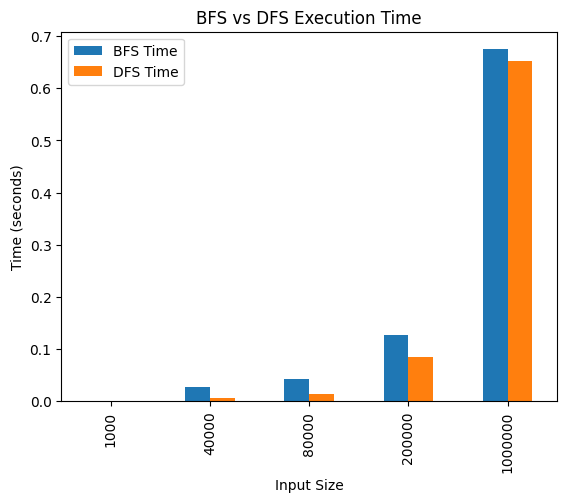

In [ ]:
# @title TASK 2

import random
import time
from collections import deque
import pandas as pd
import matplotlib.pyplot as plt

sizes = [1000, 40000, 80000, 200000, 1000000]

def build_tree(data):
    tree = {}
    for i in range(len(data)):
        tree[data[i]] = []
        left = 2*i + 1
        right = 2*i + 2

        if left < len(data):
            tree[data[i]].append(data[left])
        if right < len(data):
            tree[data[i]].append(data[right])
    return tree

def bfs(graph, start, goal):
    visited = set()
    queue = deque([start])

    while queue:
        node = queue.popleft()
        if node == goal:
            return True

        if node not in visited:
            visited.add(node)
            queue.extend(graph[node])
    return False

def dfs(graph, start, goal):
    visited = set()

    def dfs_inner(node):
        if node == goal:
            return True
        visited.add(node)

        for neighbor in graph[node]:
            if neighbor not in visited:
                if dfs_inner(neighbor):
                    return True
        return False

    return dfs_inner(start)

results = []

for size in sizes:
    data = random.sample(range(1, size * 10), size)
    tree = build_tree(data)

    start = data[0]
    goal = data[len(data) - 220]

    start_time = time.time()
    bfs(tree, start, goal)
    bfs_time = time.time() - start_time

    start_time = time.time()
    dfs(tree, start, goal)
    dfs_time = time.time() - start_time

    results.append([size, bfs_time, dfs_time])

df = pd.DataFrame(results, columns=["Size", "BFS Time", "DFS Time"])

print(df)

df.set_index("Size").plot(kind="bar")

plt.xlabel("Input Size")
plt.ylabel("Time (seconds)")
plt.title("BFS vs DFS Execution Time")

plt.show()

In [ ]:
# @title TASK 3

from collections import deque

graph = {
    "Islamabad": ["Rawalpindi", "Lahore", "Peshawar"],
    "Rawalpindi": ["Islamabad", "Peshawar", "Quetta"],
    "Peshawar": ["Islamabad", "Rawalpindi", "Quetta"],
    "Lahore": ["Islamabad", "Multan", "Quetta"],
    "Multan": ["Lahore", "Karachi", "Quetta"],
    "Quetta": ["Rawalpindi", "Peshawar", "Multan", "Karachi"],
    "Karachi": ["Multan", "Quetta"]
}

def bfs_shortest_path(graph, start, goal):
    queue = deque([[start]])
    visited = set()

    while queue:
        path = queue.popleft()
        node = path[-1]

        if node == goal:
            return path

        if node not in visited:
            visited.add(node)

            for neighbor in graph[node]:
                new_path = list(path)
                new_path.append(neighbor)
                queue.append(new_path)

    return None

if __name__ == "__main__":
    start = "Islamabad"
    goal = "Karachi"

    path = bfs_shortest_path(graph, start, goal)

    print("Shortest Path:", " → ".join(path))


Shortest Path: Islamabad → Rawalpindi → Quetta → Karachi
